In [1]:
# LVDT_simulation/tests/demo.ipynb
import sys
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from core import data_handler
from core.simulator import SimulatorManager
from core.json_handler import JsonHandler

## TypeA verification

#### LVDT

In [2]:
SimulatorManager(
    input_jsonname='../config/initial_config/typeA_lvdt.json', 
    output_filename='lvdt_result.h5', 
    output_dir="../data/typeA", 
    auto_close=False).run_simulation()


excitation voltage: 339.03
excitation current: 1.00
Fitted response: 3.26 V/mmA


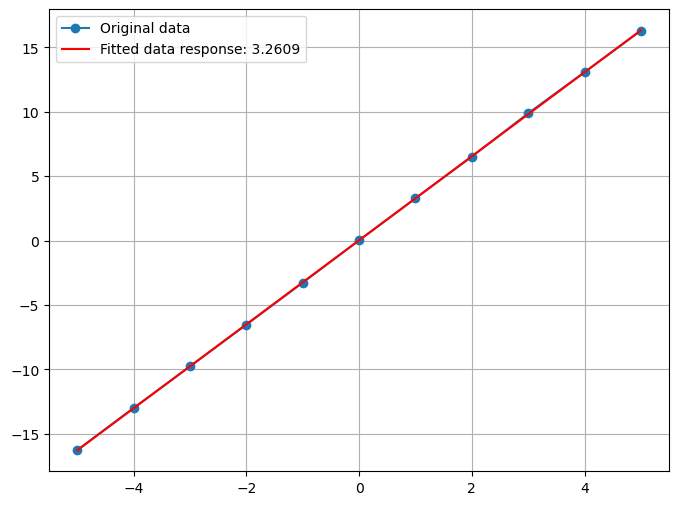

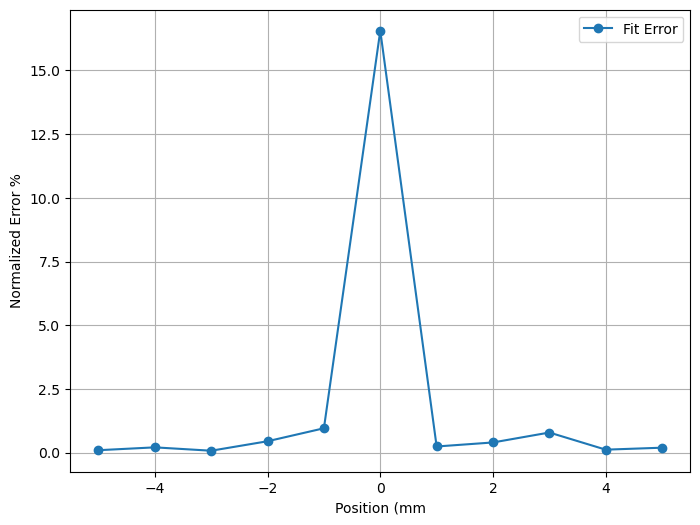

In [3]:
filename = "../data/typeA/lvdt_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=False)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
pickup_voltage_1= (volt_data['Lower_OutCoil']['voltage_abs'])
pickup_voltage_2= (volt_data['Upper_OutCoil']['voltage_abs'])
pickup_voltage = (pickup_voltage_2- pickup_voltage_1)
excitation_voltage= np.mean(abs(volt_data['Inn_Coil']['voltage_abs']))
excitation_current = np.mean(curr_data['Inn_Coil']['current_abs'])
norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current

print(f"excitation voltage: {excitation_voltage:.2f}")
print(f"excitation current: {excitation_current:.2f}")

fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")
print(f"Fitted response: {fit_params['slope']:.2f} V/mmA")
data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V")
data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)


#### VC

In [ ]:
sim_manager = SimulatorManager(input_jsonname='../config/initial_config/typeA_vc.json', output_filename='vc_result.h5', 
                                output_dir="../data/typeA", auto_close=False) 
sim_manager.run_simulation()


In [ ]:
filename = "../data/typeA/vc_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
vc_data = data_handler.get_vc_data(data_dict)

position = vc_data['position']
Upper_Coil_force = abs(vc_data['Upper_OutCoil']['force'])
Lower_Coil_force = abs(vc_data['Lower_OutCoil']['force'])
magnet_force = abs(vc_data['core_4']['force'])

plt.figure(figsize=(8,6))
plt.plot(position, Upper_Coil_force , marker = "o", label='Upper Coil')
plt.plot(position, Lower_Coil_force , marker = "*", label='Lower Coil')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(position, Upper_Coil_force + Lower_Coil_force , marker = "o", label= 'Total Force')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(position, abs(magnet_force), marker = "o", label='Magnet')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()


## Prototype Example: 2 layer coils

#### LVDT

In [3]:
sim_manager = SimulatorManager(
    input_jsonname='../config/initial_config/alucoil_lvdt_50mm.json', 
    output_filename='lvdt_alucoil_50mm_1mm_simulation.h5', 
    output_dir="../data/prototype_validation", 
    auto_close=False) 
sim_manager.run_simulation()

In [ ]:
filename = "../data/demo/lvdt_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current

data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V")
data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)

#### VC

In [2]:
sim_manager = SimulatorManager(
    input_jsonname='../config/initial_config/alucoil_vc_50mm.json', 
    output_filename='vc_alucoil_50mm_1mm_simulation.h5', 
    output_dir="../data/prototype_validation", 
    auto_close=False) 
sim_manager.run_simulation()

In [ ]:
filename = "../data/demo/vc_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
vc_data = data_handler.get_vc_data(data_dict)

position = vc_data['position']
Lower_Coil_force = vc_data['Lower_Coil']['force']
Upper_Coil_force = vc_data['Upper_Coil']['force']
Middle_Coil_force = vc_data['Middle_Coil']['force']
magnet_force = vc_data['core_4']['force']

tot_force = abs(Upper_Coil_force) + abs(Lower_Coil_force)
max_force = max(tot_force)
norm_force = (tot_force / max_force) * 100

plt.plot(position, tot_force, marker = "o", label= 'Total Force')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()

plt.plot(position, norm_force, marker = "o", label= 'Total Force Normalized')
plt.xlabel('Position (mm)')
plt.ylabel('Percentage of Maximum Force (%)')
plt.title('Force vs Position')
plt.legend()
plt.show()


#### Prototype LVDT analysis example 

In [ ]:
sim_files = ["../data/prototype_2layers/lvdt_alucoil_10mm_1mm.h5",
            "../data/prototype_2layers/lvdt_alucoil_10mm_0p1mm.h5"]

for file in sim_files:
    data_dict = data_handler.load_data(file)
    config_data = data_handler.get_config_data(data_dict)
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V")
    data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)

## Prototype Simulation vs Measurement

###  offset iteration in simulation to mimic the measurement

#### iteration process

In [ ]:
input_json_file= "../initial_config/alucoil_lvdt.json"
iter_json_file= "../iteration_config/iteration.json"
output_dir = "../data/uppcoil_offset"
uppcoil_offset = [5,6,7,8,9,10,11]
iterations = range(len(uppcoil_offset))
filename = ["lvdt_alucoil_50mm_uppcoil_offset_iter_" + str(i) + ".h5" for i in iterations]

for i in iterations:
    jsonmanager = JsonHandler(input_json=input_json_file, output_json=iter_json_file,)
    jsonmanager.update_config(["coils", 1, "offset"], uppcoil_offset[i])
    jsonmanager.save_config()

    sim_manager = SimulatorManager(input_jsonname=iter_json_file, output_filename=f'{filename[i]}', 
                                   output_dir=output_dir, auto_close=False) 
    sim_manager.run_simulation()

In [ ]:
iterations = range(6)
filename = ["lvdt_alucoil_50mm_uppcoil_offset_iter_" + str(i) + ".h5" for i in iterations]
sim_files =[f'../data/uppcoil_offset/{f}' for f in filename]

lvdt_data = {}

for i, file in enumerate(sim_files):
    data_dict = data_handler.load_data(file)

    config_data = data_handler.get_config_data(data_dict)
    iter_param = config_data['coils']['Upper_Coil']['offset']
    
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=False)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']

    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params = data_handler.linear_fit(position, norm_voltage_volt, unit="V")
    
    lvdt_data[f"iteration_{i}"] ={
        "position": position,
        "pickup_voltage": pickup_voltage,
        "fit_params": fit_params,
        'offset': iter_param,
    }

    data_handler.plot_lvdt_data(position, norm_voltage_volt, unit="V", title = f'Offset: {iter_param} mm')
# data_handler.plot_linear_fit_mutiple(data_dict = lvdt_data, xlabel = 'Position (mm)', ylabel = 'Voltage (V/mmA)',
#                                      title = 'LVDT Response vs. Upper Coil Offset')

# coil_lengths = [lvdt_data[f"iteration_{i}"]['offset'] for i in range(6)]
# responses = [lvdt_data[f"iteration_{i}"]['fit_params']['slope'] for i in range(6)]

# plt.figure(figsize=(8,6))
# plt.plot(coil_lengths, responses, 'o-')
# plt.xlabel('Coil Length (mm)')
# plt.ylabel('Response (V/mmA)')
# plt.title('LVDT Response vs. Coil Length')
# plt.grid()
# plt.show()

## Comparision

#### 1.1 lvdt: offset test

In [ ]:
# 7.6mm offset
sim_manager = SimulatorManager(input_jsonname='iteration.json', output_filename='lvdt_offset_7p6mm.h5', 
                                output_dir="../data/prototype_2layers", auto_close=False) 
sim_manager.run_simulation()


#### 1.2 lvdt: plotting 7.6mm & 7.7mm offset result

In [ ]:
filename ="../data/prototype_validation/lvdt_alucoil_50mm_1mm_simulation_offset_7p6mm.h5"
data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage')
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current

data_handler.plot_lvdt_data(position, norm_voltage_volt, unit="V", title=filename.split("/")[-1].split(".")[0])


#### 2.1 vc: offset test 

In [ ]:
# 7.6mm offset
sim_manager = SimulatorManager(
    input_jsonname='../config/initial_config/alucoil_vc_offset7p6mm.json', 
    output_filename='vc_offset_7p6mm.h5', 
    output_dir="../data/prototype_2layers", auto_close=False) 
sim_manager.run_simulation()


#### 2.2 vc: 7.6 mm offset result

In [ ]:
filenames = ["../data/prototype_validation/vc_offset_7p6mm.h5"]

for filename in filenames:
    data_dict = data_handler.load_data(filename)
    config_data = data_handler.get_config_data(data_dict)
    vc_data = data_handler.get_vc_data(data_dict)
    
    position = vc_data['position']
    tot_force = abs(vc_data['Lower_Coil']['force'])+abs(vc_data['Upper_Coil']['force'])
    norm_force = np.array(tot_force)/0.06
    max_norm_force = max(norm_force)
    fvi = ((1 - tot_force )/ max_force) * 100
    plt.figure(figsize=(8,6))
    plt.plot(position, tot_force*1000/0.06, marker = "o", label= 'Total Force')
    plt.xlabel('Position (mm)')
    plt.ylabel('Force (mN/A)')
    plt.title('Force vs Position')
    plt.legend()
    plt.tight_layout()
    # plt.savefig("simulated_force.pdf")


#### 3.1 LVDT:comparison between simualtion and measurement(with offset included)

In [ ]:
# measurement datas
exp_file = '../data/prototype_validation/lvdt_alucoil_50mm_1mm_measurement.h5'
f = h5py.File(exp_file, 'r')
exp_pos = np.array(f['PI'][:])
exp_pickup_amp = np.array(f['Fit_Amp'][:])
exp_input_waveform = np.array(f['excitation'][:])
exp_pickup_waveform = np.array(f['pick-up'][:])

exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)

# simulation data
sim_file = "../data/prototype_validation/lvdt_offset_7p6mm.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
sim_pos = lvdt_data['position']+26.3
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 

# plot
figure, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label='Experiment', color='tab:blue')
ax1.set_xlabel('Position (mm)')
ax1.set_ylabel('Norm Voltage (V/V)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(sim_pos, sim_pickup_volt_norm, marker = 'o', label='Simulation-offset 7.6 mm', color='tab:red')
ax2.set_ylabel('Norm Voltage (V/V)', color='tab:red')
ax2.legend(loc='upper right')
ax1.grid()
plt.tight_layout()
# plt.savefig('lvdt_offset_7p6mm.pdf', dpi=300, bbox_inches='tight')

#### 3.2 VC:comparison between simualtion and measurement(with offset included)

In [ ]:
# measurement datas
exp_file = '../data/prototype_validation/vc_alucoil_50mm_1mm_measurement.h5'
f = h5py.File(exp_file, 'r')
params = f['para']
time_data = f['time']
position_data = f['positions']
balance_data = f['balance']

## Default prototype: 16 layers coils

#### LVDT

In [ ]:
sim_manager = SimulatorManager(input_jsonname='../simulation/initial_config/proto_lvdt_16layers.json', output_filename='lvdt_result.h5', 
                                output_dir="../simulation/data/prototype_16layers", auto_close=False) 
sim_manager.run_simulation()

In [ ]:
filename = "../simulation/data/prototype_16layers/lvdt_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

norm_voltage_volt = (pickup_voltage / excitation_voltage) * 70
norm_voltage_curr = (pickup_voltage / excitation_current) * 70

data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V", ylabel="Response (V/mmA)", xlabel="Position (mm)")
data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)

#### VC

In [ ]:
sim_manager = SimulatorManager(input_jsonname='../simulation/initial_config/proto_vc_16layers.json', output_filename='vc_result.h5', 
                                output_dir="../simulation/data/prototype_16layers", auto_close=False) 
sim_manager.run_simulation()

In [ ]:
filename = "../simulation/data/prototype_16layers/vc_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
vc_data = data_handler.get_vc_data(data_dict)

position = vc_data['position']
Lower_Coil_force = vc_data['Lower_Coil']['force']
Upper_Coil_force = vc_data['Upper_Coil']['force']
Middle_Coil_force = vc_data['Middle_Coil']['force']
magnet_force = vc_data['core_4']['force']

tot_force = abs(Upper_Coil_force) + abs(Lower_Coil_force)
norm_force = (tot_force / max(tot_force)) * 100

plt.plot(position, tot_force, marker = "o", label= 'Total Force')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()

plt.plot(position, norm_force, marker = "o", label= 'Total Force Normalized')
plt.xlabel('Position (mm)')
plt.ylabel('Percentage of Maximum Force (%)')
plt.title('Force vs Position')
plt.legend()
plt.show()
